# Tutorial: Multiple Myeloma Datasets
## Notebook 02 — Training and Evaluation with YOLO26

This notebook trains and evaluates an object detector for plasma cell detection on **Dataset 1** (Andrade et al., 2024, *Scientific Reports*), using **YOLO26** — the latest Ultralytics YOLO release — instead of the YOLOv7 originally used in the paper.

**What you will learn:**
- How to describe a YOLO-format dataset with a `data.yaml` file
- How to fine-tune a pretrained YOLO26 model on a custom dataset
- How to read training curves (loss, precision, recall, mAP)
- How to evaluate a trained model on a held-out test set
- How to visualize predictions against ground-truth annotations

**Note on scale:** this notebook favors a fast, live-runnable demo (nano model, ~25 epochs, 640px images) over state-of-the-art accuracy. For production-quality results, train a larger model (`yolo26s`/`yolo26m`) for more epochs.

---
## 0. Environment Setup

In [1]:
!pip install -q ultralytics

In [1]:
import os
import shutil
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from huggingface_hub import hf_hub_download
from ultralytics import YOLO

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 9

DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'Environment configured. Training device: {device_name}')

Environment configured. Training device: NVIDIA T600 Laptop GPU


---
## Part 1 — Dataset Preparation
### 1.1 Download Dataset 1 (if needed)

Same source used in `01_image_presentation.ipynb`: a sample fold of the Multiple Myeloma Dataset (Andrade et al., 2024), hosted on Hugging Face.

In [2]:
DS1_DIR = DATA_DIR / 'dataset1'
DS1_ZIP = DATA_DIR / 'myeloma_dataset_conf_fold_1.zip'

if not DS1_DIR.exists():
    print('Downloading Dataset 1 (sample fold) from Hugging Face...')
    local_path = hf_hub_download(
        repo_id='LAB-IA-UFBA/myeloma-dataset',
        filename='myeloma_dataset_conf_fold_1.zip',
        repo_type='dataset',
        local_dir=str(DATA_DIR)
    )
    print(f'Download complete: {local_path}')
    print('Extracting files...')
    with zipfile.ZipFile(local_path, 'r') as zf:
        zf.extractall(DS1_DIR)
    print('Extraction complete.')
else:
    print(f'Dataset 1 already available at {DS1_DIR}')

FOLD_DIR = DS1_DIR / 'fold_1'


Dataset 1 already available at data/dataset1


### 1.2 Inspect Class Distribution per Split

YOLO training needs a `data.yaml` describing the classes. Let's check which classes actually appear in the labels of this fold before writing it.

In [3]:
def collect_classes(split_dir):
    """Return the set of class ids found in a split's label files."""
    classes = set()
    label_dir = split_dir / 'labels'
    for lbl_file in label_dir.glob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    classes.add(int(parts[0]))
    return classes

for split in ['train', 'val', 'test']:
    split_dir = FOLD_DIR / split
    n_images = len(list((split_dir / 'images').glob('*.jpg')))
    classes = collect_classes(split_dir)
    print(f'{split:5s}: {n_images:4d} images | classes present: {sorted(classes)}')

train:  409 images | classes present: [0]
val  :   50 images | classes present: [0]
test :   53 images | classes present: [0]


Only **class 0 (Plasma Cell)** is annotated in this fold — matching the label distribution found in `01_image_presentation.ipynb`. We'll therefore configure a **single-class** detection task.

### 1.3 Write the `data.yaml` Config

In [4]:
DATA_YAML = FOLD_DIR / 'data.yaml'

data_yaml_content = f'''path: {FOLD_DIR.resolve()}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['Plasma Cell']
'''

DATA_YAML.write_text(data_yaml_content)
print(f'Config written to {DATA_YAML}\n')
print(data_yaml_content)

Config written to data/dataset1/fold_1/data.yaml

path: /home/rios/projects/tutorial-MM/data/dataset1/fold_1
train: train/images
val: val/images
test: test/images

nc: 1
names: ['Plasma Cell']



---
## Part 2 — Fine-Tuning YOLO26

We start from `yolo26n.pt`, the nano checkpoint pretrained on COCO, and fine-tune it on our plasma cell detection task. The nano model keeps training time short enough to run live on modest hardware (e.g. a laptop GPU).

In [6]:
EPOCHS = 25
IMG_SIZE = 640
BATCH = 8
RUN_NAME = 'ds1_yolo26n'

model = YOLO('yolo26n.pt')

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    seed=0,
    name=RUN_NAME,
    exist_ok=True,
    patience=EPOCHS,  # disable early stopping for this short demo run
)

RUN_DIR = Path(results.save_dir)
print(f'\nTraining finished. Artifacts saved to: {RUN_DIR}')

New https://pypi.org/project/ultralytics/8.4.89 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.84 🚀 Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA T600 Laptop GPU, 3721MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset1/fold_1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scal

---
## Part 3 — Training Curves

Ultralytics logs per-epoch metrics to `results.csv` inside the run directory. Let's plot the loss and validation metrics to check convergence.

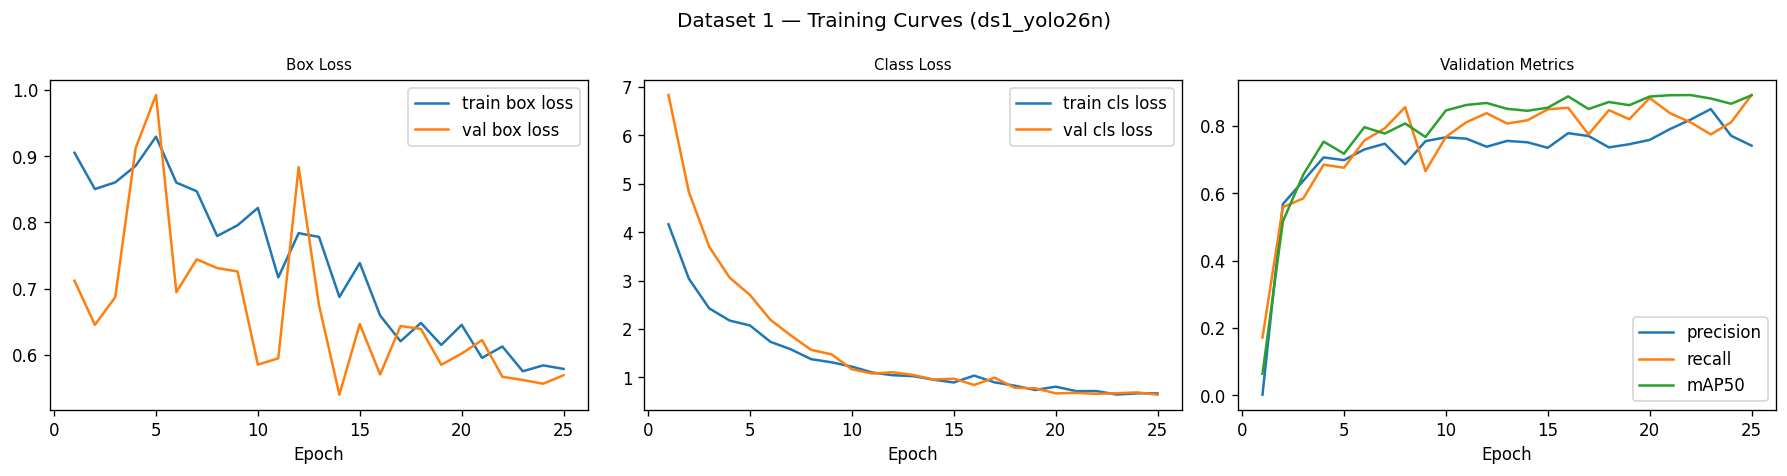

In [7]:
%matplotlib inline
history = pd.read_csv(RUN_DIR / 'results.csv')
history.columns = [c.strip() for c in history.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Dataset 1 — Training Curves ({RUN_NAME})', fontsize=12)

axes[0].plot(history['epoch'], history['train/box_loss'], label='train box loss')
axes[0].plot(history['epoch'], history['val/box_loss'], label='val box loss')
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['epoch'], history['train/cls_loss'], label='train cls loss')
axes[1].plot(history['epoch'], history['val/cls_loss'], label='val cls loss')
axes[1].set_title('Class Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['epoch'], history['metrics/precision(B)'], label='precision')
axes[2].plot(history['epoch'], history['metrics/recall(B)'], label='recall')
axes[2].plot(history['epoch'], history['metrics/mAP50(B)'], label='mAP50')
axes[2].set_title('Validation Metrics')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Part 4 — Evaluation on the Held-Out Test Set

Everything so far used the **validation** split to monitor training. Now we evaluate the best checkpoint on the **test** split, which the model never saw during training.

In [8]:
best_model = YOLO(RUN_DIR / 'weights' / 'best.pt')

test_metrics = best_model.val(data=str(DATA_YAML), split='test', device=DEVICE)

print('=== Test Set Metrics ===')
print(f'Precision : {test_metrics.results_dict["metrics/precision(B)"]:.3f}')
print(f'Recall    : {test_metrics.results_dict["metrics/recall(B)"]:.3f}')
print(f'mAP@50    : {test_metrics.results_dict["metrics/mAP50(B)"]:.3f}')
print(f'mAP@50-95 : {test_metrics.results_dict["metrics/mAP50-95(B)"]:.3f}')

Ultralytics 8.4.84 🚀 Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA T600 Laptop GPU, 3721MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4191.7±401.3 MB/s, size: 1442.9 KB)
val: Scanning /home/rios/projects/tutorial-MM/data/dataset1/fold_1/test/labels.cache... 53 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 53/53 12.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1it/s 3.6s1.3ss
                   all         53        160      0.799      0.868      0.868      0.773
Speed: 7.4ms preprocess, 14.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/rios/projects/tutorial-MM/runs/detect/val-3
=== Test Set Metrics ===
Precision : 0.799
Recall    : 0.868
mAP@50    : 0.868
mAP@50-95 : 0.773


### 4.1 Confusion Matrix and PR Curve

`model.val()` also saves diagnostic plots to its run directory. Let's display them.

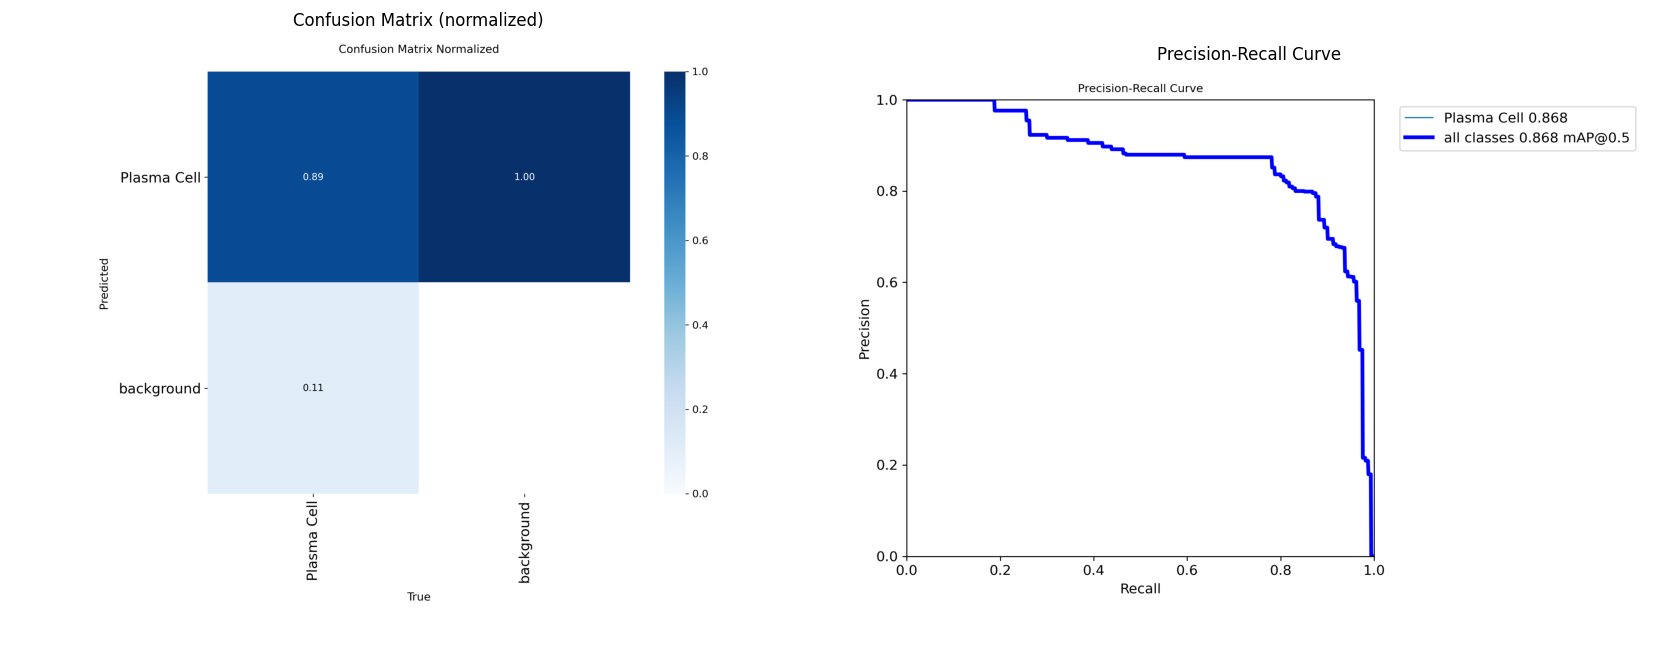

In [9]:
%matplotlib inline
val_run_dir = Path(test_metrics.save_dir)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fname, title in zip(
    axes,
    ['confusion_matrix_normalized.png', 'BoxPR_curve.png'],
    ['Confusion Matrix (normalized)', 'Precision-Recall Curve'],
):
    img_path = val_run_dir / fname
    if img_path.exists():
        ax.imshow(plt.imread(img_path))
        ax.set_title(title, fontsize=10)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Part 5 — Visualizing Predictions vs. Ground Truth

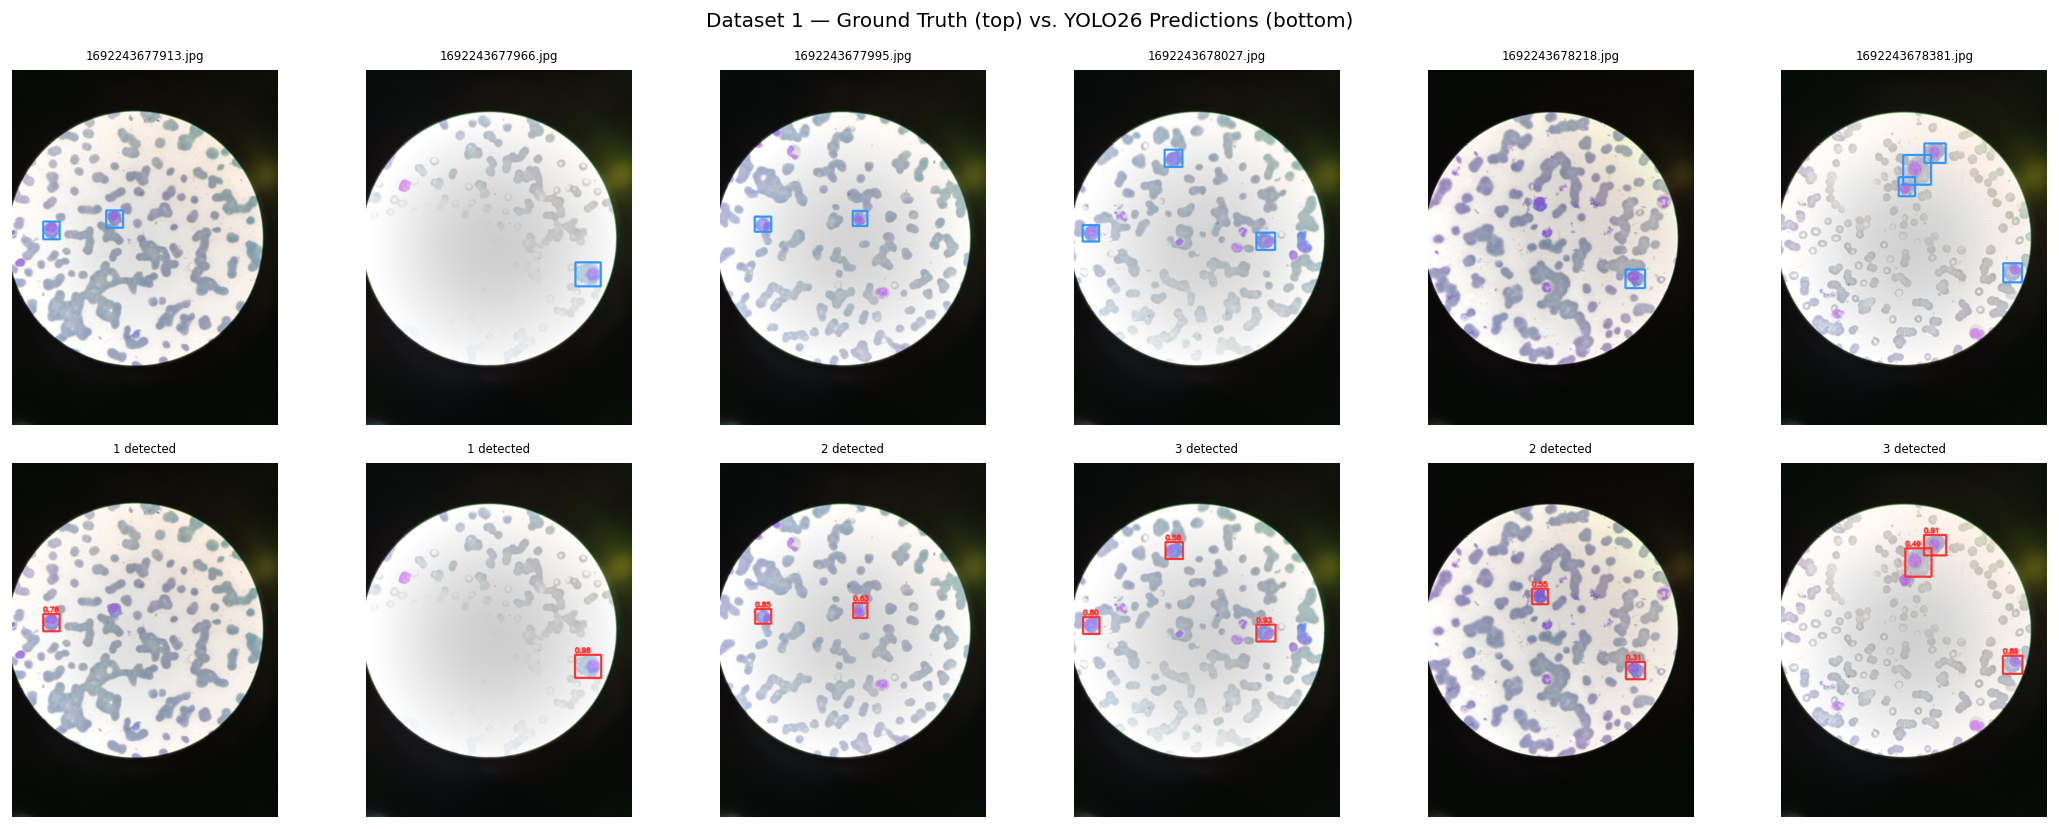

In [14]:
%matplotlib inline
def load_rgb(path, max_dim=800):
    """Read an image, convert to RGB, and downscale for display.

    The source images are much larger (e.g. 4608x3456) than the space each
    subplot gets below, so box thickness set in full-resolution pixels would
    shrink to a sliver on screen. Downscaling first makes a given thickness
    actually visible.
    """
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    scale = max_dim / max(img.shape[:2])
    if scale < 1:
        new_size = (int(img.shape[1] * scale), int(img.shape[0] * scale))
        img = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)
    return img


def draw_gt_boxes(img, label_path, color=(50, 150, 255), thickness=4):
    """Draw ground-truth YOLO boxes on an image (numpy RGB)."""
    img_out = img.copy()
    H, W = img_out.shape[:2]
    if not label_path.exists():
        return img_out
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = int((cx - bw / 2) * W)
            y1 = int((cy - bh / 2) * H)
            x2 = int((cx + bw / 2) * W)
            y2 = int((cy + bh / 2) * H)
            cv2.rectangle(img_out, (x1, y1), (x2, y2), color, thickness)
    return img_out


def draw_pred_boxes(img, result, color=(255, 50, 50), thickness=4):
    """Draw predicted boxes on an image (numpy RGB), labeled with confidence.

    `result` was computed on the full-resolution image, so box coordinates
    are scaled down to match the already-resized `img` before drawing.
    """
    img_out = img.copy()
    H, W = img_out.shape[:2]
    orig_H, orig_W = result.orig_shape
    sx, sy = W / orig_W, H / orig_H
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        x1, x2 = int(x1 * sx), int(x2 * sx)
        y1, y2 = int(y1 * sy), int(y2 * sy)
        conf = float(box.conf[0])
        cv2.rectangle(img_out, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(img_out, f'{conf:.2f}', (x1, max(y1 - 5, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)
    return img_out


test_images = sorted((FOLD_DIR / 'test' / 'images').glob('*.jpg'))
n = min(6, len(test_images))
predictions = best_model.predict(test_images[:n], device=DEVICE, verbose=False)

fig, axes = plt.subplots(2, n, figsize=(3 * n, 7))
fig.suptitle('Dataset 1 — Ground Truth (top) vs. YOLO26 Predictions (bottom)', fontsize=12)

for col, (img_path, result) in enumerate(zip(test_images[:n], predictions)):
    img = load_rgb(img_path)
    label_path = Path(str(img_path).replace('/images/', '/labels/')).with_suffix('.txt')

    gt_img = draw_gt_boxes(img, label_path)
    axes[0, col].imshow(gt_img)
    axes[0, col].set_title(img_path.name, fontsize=7)
    axes[0, col].axis('off')

    pred_img = draw_pred_boxes(img, result)
    axes[1, col].imshow(pred_img)
    axes[1, col].set_title(f'{len(result.boxes)} detected', fontsize=7)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

---
## Summary

In this notebook you learned how to:

1. **Describe** a YOLO-format dataset with a `data.yaml` file
2. **Fine-tune** a pretrained YOLO26 nano model on plasma cell detection
3. **Read** training curves (losses, precision, recall, mAP)
4. **Evaluate** a trained model on a held-out test split
5. **Visualize** predictions against ground-truth annotations

**Ideas to extend this notebook:**
- Train on more folds and average metrics across the 10-fold cross-validation
- Try a larger model (`yolo26s`, `yolo26m`) or more epochs for higher accuracy
- Repeat the same pipeline on Dataset 2 (PCMMD), including the segmentation task

**References:**
- Andrade et al. (2024). *Multiple Myeloma Dataset*. Scientific Reports, 14, 11176. https://doi.org/10.1038/s41598-024-61420-9
- Ultralytics YOLO26. https://docs.ultralytics.com/